
SGD
  Phase 1 done — final accs: ['0.98', '0.12', '0.11']
  Phase 2 done — final accs: ['0.80', '0.98', '0.15']
  Phase 3 done — final accs: ['0.30', '0.83', '0.98']

L2
  Phase 1 done — final accs: ['0.98', '0.12', '0.11']
  Phase 2 done — final accs: ['0.98', '0.13', '0.11']
  Phase 3 done — final accs: ['0.98', '0.13', '0.11']

EWC
  Phase 1 done — final accs: ['0.98', '0.12', '0.11']
  Phase 2 done — final accs: ['0.92', '0.98', '0.16']
  Phase 3 done — final accs: ['0.76', '0.92', '0.98']


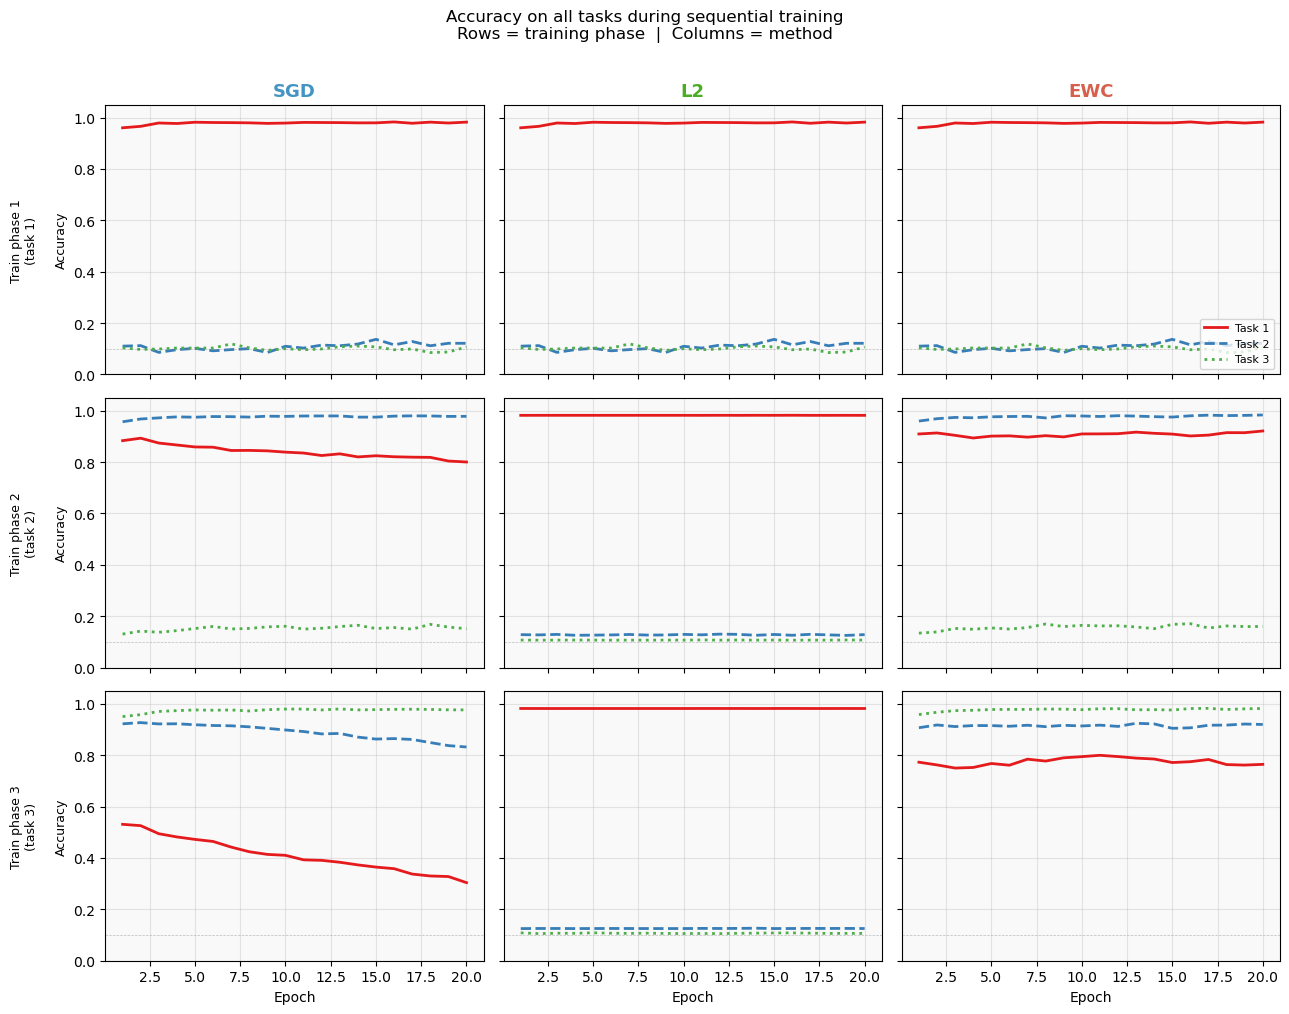

In [ ]:


import torch
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# ── Config ───────────────────────────────────────────────────
EPOCHS = 20
BATCH  = 256
LR     = 1e-3
HIDDEN = 400
LAM    = {'sgd': 0, 'l2': 400.0, 'ewc': 400.0} # regularization strength (same for both EWC and L2)
SEED   = 42
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Data ─────────────────────────────────────────────────────
def make_task(perm, train_ds, test_ds):
    def loader(ds, shuffle):
        def collate(batch):
            x = torch.stack([img.view(-1)[perm] for img, _ in batch])   #
            y = torch.tensor([lbl for _, lbl in batch])
            return x, y
        return DataLoader(ds, BATCH, shuffle=shuffle, collate_fn=collate)
    return loader(train_ds, True), loader(test_ds, False)

torch.manual_seed(SEED)
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=tf)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=tf)
tasks = [make_task(p, train_ds, test_ds) for p in
         [torch.arange(784), torch.randperm(784), torch.randperm(784)]]
#now, we have 3 tasks, each with a different random pixel permutation. The first task is unpermuted (identity), and the next two are random permutations of the pixel order.

# ── Model ────────────────────────────────────────────────────
def make_model():
    return torch.nn.Sequential(
        torch.nn.Linear(784, HIDDEN), torch.nn.ReLU(),
        torch.nn.Linear(HIDDEN, HIDDEN), torch.nn.ReLU(),
        torch.nn.Linear(HIDDEN, 10),
    ).to(device)

# ── Fisher ───────────────────────────────────────────────────
def compute_fisher(model, loader): # computes diagonal of Fisher information matrix for current model parameters. Done by accumulating squared gradients of log-likelihood loss over dataset, which serves as an estimate of how important each parameter is for the task at hand.
    fisher = {n: torch.zeros_like(p) for n, p in model.named_parameters()} # initialize a dict to accumulate squared gradients for each parameter
    model.eval() 
    for x, y in loader: #loader here is the training data for the current task
        model.zero_grad()
        F.nll_loss(F.log_softmax(model(x.to(device)), 1), y.to(device)).backward() # compute log-likelihood loss and backprop to get gradients
        for n, p in model.named_parameters(): # accumulate squared gradients into the fisher dict
            fisher[n] += p.grad.detach() ** 2 # accumulate squared gradients for this batch
    return {n: v / len(loader) for n, v in fisher.items()}

# ── Train one epoch ──────────────────────────────────────────
def train_epoch(model, loader, opt, method, old_snaps=None, fisher=None):
    """
    old_snaps : for EWC  → a single param-dict (the latest snapshot)
                for L2   → a LIST of param-dicts (one per completed task)
    fisher    : accumulated Fisher dict (EWC only)
    """
    model.train()
    for x, y in loader:
        opt.zero_grad()
        loss = F.cross_entropy(model(x.to(device)), y.to(device))

        if method == 'ewc' and old_snaps is not None:
            # EWC: one anchor (latest snap) with accumulated Fisher weights
            penalty = sum(
                (fisher[n] * (p - old_snaps[n]).pow(2)).sum()
                for n, p in model.named_parameters()
            )
            loss += (LAM['ewc'] / 2) * penalty

        elif method == 'l2' and old_snaps:
            # L2: sum uniform-weight penalties over ALL previous task snapshots
            # This mirrors EWC's accumulation — each past task contributes equally
            penalty = sum(
                (p - snap[n]).pow(2).sum()
                for snap in old_snaps          # ← iterate over every saved snap
                for n, p in model.named_parameters()
            )
            loss += (LAM['l2'] / 2) * penalty

        loss.backward()
        opt.step()

def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            correct += (model(x.to(device)).argmax(1) == y.to(device)).sum().item()
            total   += len(y)
    return correct / total




# ── Experiment ───────────────────────────────────────────────
results = {}

for method in ['sgd', 'l2', 'ewc']:
    print(f"\n{method.upper()}")
    torch.manual_seed(SEED)
    model  = make_model()
    opt    = optim.Adam(model.parameters(), lr=LR)
    fisher = None

    # EWC uses a single (latest) snap dict; L2 uses a growing list of snaps. If we want them to train on same 
    ewc_snap  = None   # single dict for EWC
    l2_snaps  = []     # list of dicts for L2

    results[method] = []

    for phase, task_idx in enumerate([0, 1, 2]):
        train_loader, _ = tasks[task_idx]
        curves = [[] for _ in range(3)]

        for epoch in range(EPOCHS):
            if method == 'ewc':
                train_epoch(model, train_loader, opt, method,
                            old_snaps=ewc_snap, fisher=fisher)
            elif method == 'l2':
                train_epoch(model, train_loader, opt, method,
                            old_snaps=l2_snaps)          # pass the full list
            else:  # sgd
                train_epoch(model, train_loader, opt, method)

            for i in range(3):
                curves[i].append(accuracy(model, tasks[i][1]))

        results[method].append(curves)

        # ── Update anchors after each phase ──────────────────
        new_snap = {n: p.clone().detach() for n, p in model.named_parameters()}
        ewc_snap = new_snap                  # EWC always anchors to latest snap
        l2_snaps.append(new_snap)            # L2 accumulates all snaps

        if method == 'ewc':
            new_f  = compute_fisher(model, train_loader)
            fisher = {n: fisher[n] + new_f[n] for n in new_f} if fisher else new_f

        print(f"  Phase {phase+1} done — final accs: "
              f"{[f'{curves[i][-1]:.2f}' for i in range(3)]}")


















# ── Plot ─────────────────────────────────────────────────────
method_colors = {'sgd': '#4393c3', 'l2': '#4dac26', 'ewc': '#d6604d'}
task_styles   = ['-', '--', ':']
task_colors   = ['#e41a1c', '#377eb8', '#4daf4a']

fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
epochs = np.arange(1, EPOCHS + 1)

for col, method in enumerate(['sgd', 'l2', 'ewc']):
    for row, phase in enumerate([0, 1, 2]):
        ax = axes[row][col]
        curves = results[method][phase]

        for i in range(3):
            ax.plot(epochs, curves[i],
                    color=task_colors[i],
                    linestyle=task_styles[i],
                    linewidth=2,
                    label=f'Task {i+1}')

        ax.set_facecolor('#f9f9f9')
        ax.axhline(0.1, color='gray', linewidth=0.5, linestyle='--', alpha=0.5)

        if row == 0:
            ax.set_title(method.upper(), fontsize=13, fontweight='bold',
                         color=method_colors[method])
        if col == 0:
            ax.set_ylabel(f'Train phase {phase+1}\n(task {phase+1})\n\nAccuracy', fontsize=9)
        if row == 2:
            ax.set_xlabel('Epoch', fontsize=10)
        if row == 0 and col == 2:
            ax.legend(loc='lower right', fontsize=8)

        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

plt.suptitle('Accuracy on all tasks during sequential training\n'
             'Rows = training phase  |  Columns = method', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('ewc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

Loading MNIST via scikit-learn (downloads once, then cached) …
  Done.  3 tasks |  train: 60000 samples  |  test: 10000 samples



/var/folders/52/spb42hgd13d9lwpjchpxy8z80000gn/T/ipykernel_37634/2924640025.py:138: RuntimeWarning: overflow encountered in matmul
  z2 = a1 @ model["W2"] + model["b2"]   # linear transform
/var/folders/52/spb42hgd13d9lwpjchpxy8z80000gn/T/ipykernel_37634/2924640025.py:97: RuntimeWarning: invalid value encountered in subtract
  shifted = x - x.max(axis=1, keepdims=True)


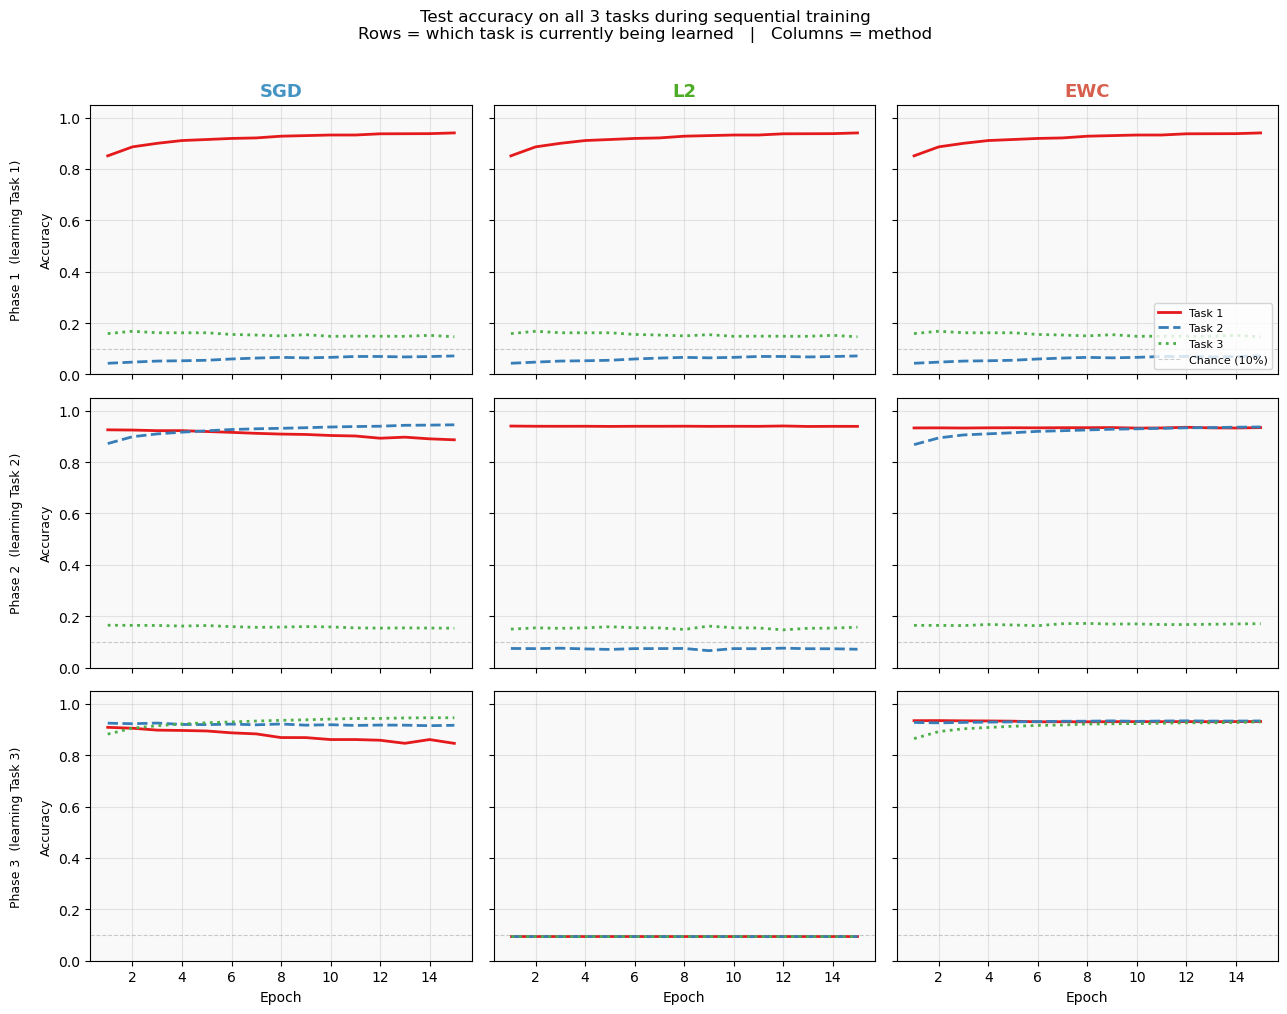

Plot saved → catastrophic_forgetting.png


In [4]:
"""
Catastrophic Forgetting Demo  —  Pure NumPy, no PyTorch
========================================================
Three methods are compared on Permuted-MNIST sequential learning:

  SGD  : plain gradient descent  → severe forgetting expected
  L2   : uniform penalty toward old parameters  → moderate protection
  EWC  : Fisher-weighted penalty (Elastic Weight Consolidation)  → best protection

Structure
─────────
  STEP 1 – Create the 3 permuted-MNIST datasets
  STEP 2 – Train each method sequentially on the 3 tasks
  STEP 3 – Plot accuracy curves

Requirements:  numpy  matplotlib  scikit-learn
Install:  pip install numpy matplotlib scikit-learn
"""

import numpy as np
import matplotlib.pyplot as plt

# ──────────────────────────────────────────────────────────────
# CONFIGURATION
# ──────────────────────────────────────────────────────────────
SEED       = 42
EPOCHS     = 15        # epochs per task
BATCH_SIZE = 256
LR         = 0.01      # learning rate (plain SGD)
HIDDEN     = 400       # hidden units per layer

LAMBDA_L2  = 100       # L2 penalty weight (per previous snapshot)
LAMBDA_EWC = 200.0      # EWC penalty weight

np.random.seed(SEED)


# ══════════════════════════════════════════════════════════════
# STEP 1 – CREATE THE 3 PERMUTED-MNIST DATASETS
# ══════════════════════════════════════════════════════════════
#   Task 1 = original pixel order
#   Task 2 = one random pixel shuffle
#   Task 3 = a different random pixel shuffle

print("Loading MNIST via scikit-learn (downloads once, then cached) …")
from sklearn.datasets import fetch_openml

mnist_data = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
x_all = mnist_data.data.astype(np.float32) / 255.0   # (70000, 784), values in [0, 1]
y_all = mnist_data.target.astype(np.int32)            # (70000,), labels 0–9

# Standard MNIST split
x_train, x_test = x_all[:60000], x_all[60000:]
y_train, y_test = y_all[:60000], y_all[60000:]

# ── Define 3 pixel permutations ──
perm_task1 = np.arange(784)              # identity: original MNIST
perm_task2 = np.random.permutation(784) # random shuffle A
perm_task3 = np.random.permutation(784) # random shuffle B

# ── Apply permutations to build the 3 datasets ──
# tasks_train[i] = (x, y) for task i, training split
# tasks_test[i]  = (x, y) for task i, test split
tasks_train = [
    (x_train[:, perm_task1], y_train),
    (x_train[:, perm_task2], y_train),
    (x_train[:, perm_task3], y_train),
]
tasks_test = [
    (x_test[:, perm_task1], y_test),
    (x_test[:, perm_task2], y_test),
    (x_test[:, perm_task3], y_test),
]

print(f"  Done.  3 tasks |  train: {len(x_train)} samples  |  test: {len(x_test)} samples\n")


# ══════════════════════════════════════════════════════════════
# STEP 2 – MODEL + TRAINING FUNCTIONS
# ══════════════════════════════════════════════════════════════

# ─── Activation and loss helpers ─────────────────────────────

def relu(x):
    """ReLU activation: max(0, x)."""
    return np.maximum(0.0, x)

def relu_grad(x):
    """Derivative of ReLU: 1 where x > 0, else 0."""
    return (x > 0).astype(np.float32)

def softmax(x):
    """
    Row-wise softmax: converts raw logits to probabilities.
    We subtract the row maximum first to avoid numerical overflow.
    """
    shifted = x - x.max(axis=1, keepdims=True)
    exp_x   = np.exp(shifted)
    return exp_x / exp_x.sum(axis=1, keepdims=True)


# ─── Model ───────────────────────────────────────────────────
# We represent the network as a plain dict of NumPy arrays.
# Architecture: 784 → HIDDEN → HIDDEN → 10
# W1/b1 = layer 1 weights/bias
# W2/b2 = layer 2 weights/bias
# W3/b3 = output layer weights/bias

def make_model():
    """
    Initialisation (std = sqrt(2 / fan_in)) keeps gradients well-scaled when using ReLU activations.
    """
    np.random.seed(SEED)
    return {
        "W1": np.random.randn(784,    HIDDEN) * np.sqrt(2.0 / 784),
        "b1": np.zeros(HIDDEN),
        "W2": np.random.randn(HIDDEN, HIDDEN) * np.sqrt(2.0 / HIDDEN),
        "b2": np.zeros(HIDDEN),
        "W3": np.random.randn(HIDDEN, 10)     * np.sqrt(2.0 / HIDDEN),
        "b3": np.zeros(10),
    }


# ─── Forward pass ────────────────────────────────────────────

def forward(model, x):
    """
    Run a batch of inputs (shape: batch × 784) through the network.

    Returns
    -------
    logits : (batch × 10)  raw output scores, one per class
    cache  : intermediate values needed to compute gradients in the backward pass
    """
    z1 = x  @ model["W1"] + model["b1"]   # linear transform
    a1 = relu(z1)                           # ReLU activation

    z2 = a1 @ model["W2"] + model["b2"]   # linear transform
    a2 = relu(z2)                           # ReLU activation

    z3 = a2 @ model["W3"] + model["b3"]   # output logits (no activation here)

    cache = {"x": x, "z1": z1, "a1": a1, "z2": z2, "a2": a2}
    return z3, cache


# ─── Backward pass ───────────────────────────────────────────

def backward(model, logits, labels, cache):
    """
    Compute gradients of the cross-entropy loss w.r.t. all model parameters.

    Cross-entropy + softmax gradient at the output:
      dL/dz3 = (softmax(z3) − one_hot(labels)) / n

    Then we apply the chain rule layer by layer back to the input.

    Returns a dict with the same keys as the model, containing gradients.
    """
    n     = len(labels)
    probs = softmax(logits)

    # ── Output layer gradients ──
    dz3 = probs.copy()
    dz3[np.arange(n), labels] -= 1   # subtract 1 at the correct class
    dz3 /= n                          # average over the batch

    dW3 = cache["a2"].T @ dz3
    db3 = dz3.sum(axis=0)

    # ── Layer 2 gradients (chain rule through ReLU) ──
    da2 = dz3 @ model["W3"].T
    dz2 = da2 * relu_grad(cache["z2"])  # gate: zero out where ReLU was off

    dW2 = cache["a1"].T @ dz2
    db2 = dz2.sum(axis=0)

    # ── Layer 1 gradients ──
    da1 = dz2 @ model["W2"].T
    dz1 = da1 * relu_grad(cache["z1"])

    dW1 = cache["x"].T @ dz1
    db1 = dz1.sum(axis=0)

    return {"W1": dW1, "b1": db1, "W2": dW2, "b2": db2, "W3": dW3, "b3": db3}


# ─── Accuracy ────────────────────────────────────────────────

def compute_accuracy(model, x, y):
    """Run the model on (x, y) and return the fraction of correct predictions."""
    logits, _ = forward(model, x)
    predictions = logits.argmax(axis=1)
    return (predictions == y).mean()


# ─── Snapshot ────────────────────────────────────────────────

def snapshot(model):
    """
    Save a deep copy of the model's current parameters.
    Used as an 'anchor': the parameter values we want to stay close to.
    """
    return {key: model[key].copy() for key in model}


# ─── Fisher Information (EWC only) ───────────────────────────

def compute_fisher(model, x, y, n_samples=500):
    """
    Compute the diagonal of the Fisher Information Matrix.

    The Fisher diagonal tells us how *important* each parameter is
    for the current task.  Parameters with a high Fisher value have a
    strong influence on the loss, so changing them will hurt performance.

    We approximate it as the average of squared gradients over individual
    training samples:
        F_i ≈ (1/N) Σ_samples  (dL/dθ_i)²

    High Fisher → protect this parameter more in future tasks.
    """
    fisher = {key: np.zeros_like(model[key]) for key in model} # model is of size

    # Use a random subset for speed
    idx = np.random.choice(len(x), n_samples, replace=False)

    for i in idx:
        xi = x[i : i + 1]   # single sample, shape (1, 784)
        yi = y[i : i + 1]   # single label,  shape (1,)

        logits, cache = forward(model, xi)
        grads         = backward(model, logits, yi, cache)

        for key in model:
            fisher[key] += grads[key] ** 2   # squared gradient

    for key in model:
        fisher[key] /= n_samples             # average

    return fisher


# ─── Train on one task ───────────────────────────────────────

def train_one_task(model, task_x, task_y, method,
                   old_snapshots, accumulated_fisher, ewc_anchor):
    """
    Train the model for EPOCHS epochs on a single task.

    After each epoch, test accuracy on all 3 tasks is recorded so we can
    see which method forgets and which one preserves old knowledge.

    Parameters
    ----------
    model               : current model dict (modified in-place)
    task_x, task_y      : training data for the current task
    method              : 'sgd', 'l2', or 'ewc'
    old_snapshots       : list of param snapshots (one per past task) – for L2
    accumulated_fisher  : sum of Fisher diagonals over past tasks      – for EWC
    ewc_anchor          : param snapshot of the last completed task    – for EWC

    Returns
    -------
    accuracy_curves : list of 3 lists, each of length EPOCHS
                      accuracy_curves[i][epoch] = test acc on task i after that epoch
    """
    n               = len(task_x)
    accuracy_curves = [[], [], []]   # one curve per task

    for epoch in range(EPOCHS):

        # ── Mini-batch gradient descent ──────────────────────
        batch_order = np.random.permutation(n)

        for start in range(0, n, BATCH_SIZE):
            batch_idx = batch_order[start : start + BATCH_SIZE]
            xb = task_x[batch_idx]
            yb = task_y[batch_idx]

            # Standard cross-entropy gradients
            logits, cache = forward(model, xb)
            grads         = backward(model, logits, yb, cache)

            # ── L2 regularisation ────────────────────────────
            # Idea: after finishing Task k, we save its parameters as a snapshot.
            # While training on Task k+1, we add a penalty that pulls the current
            # parameters back toward every previous snapshot.
            #
            # penalty  = (λ/2) * Σ_{past tasks}  ||θ − θ_old||²
            # gradient = λ     * Σ_{past tasks}  (θ − θ_old)      ← added below
            #
            # Every parameter is equally penalised (no notion of importance).
            if method == "l2":
                for snap in old_snapshots:
                    for key in model:
                        grads[key] += LAMBDA_L2 * (model[key] - snap[key])

            # ── EWC regularisation ───────────────────────────
            # Same pull-back idea as L2, but the penalty on each parameter is
            # *scaled by its Fisher value*: important parameters get a stronger
            # pull, unimportant ones are left freer to adapt.
            #
            # penalty  = (λ/2) * Σ_params  F_i * (θ_i − θ*_i)²
            # gradient = λ     * Σ_params  F_i * (θ_i − θ*_i)    ← added below
            if method == "ewc" and ewc_anchor is not None:
                for key in model:
                    grads[key] += (
                        LAMBDA_EWC
                        * accumulated_fisher[key]
                        * (model[key] - ewc_anchor[key])
                    )

            # ── Gradient descent step ─────────────────────────
            for key in model:
                model[key] -= LR * grads[key]

        # ── Evaluate on all 3 test sets after this epoch ─────
        for task_id in range(3):
            tx, ty = tasks_test[task_id]
            acc    = compute_accuracy(model, tx, ty)
            accuracy_curves[task_id].append(acc)

    return accuracy_curves


# ══════════════════════════════════════════════════════════════
# STEP 2 (cont.) – RUN THE FULL SEQUENTIAL EXPERIMENT
# ══════════════════════════════════════════════════════════════
#
# For each method we train sequentially: Task 1 → Task 2 → Task 3.
# results[method][phase] = [curve_task0, curve_task1, curve_task2]
#   where curve_taskN[epoch] = test accuracy on Task N at that epoch.

results = {}

for method in ["sgd", "l2", "ewc"]:
    np.random.seed(SEED)
    model = make_model()

    # State that grows across tasks:
    old_snapshots      = []   # L2  : one snapshot per completed task
    accumulated_fisher = None # EWC : running sum of Fisher diagonals
    ewc_anchor         = None # EWC : params at end of last completed task

    results[method] = []

    for task_id in range(3):
        task_x, task_y = tasks_train[task_id]

        accuracy_curves = train_one_task(
            model, task_x, task_y, method,
            old_snapshots      = old_snapshots,
            accumulated_fisher = accumulated_fisher,
            ewc_anchor         = ewc_anchor,
        )
        results[method].append(accuracy_curves)

        final = [f"{accuracy_curves[i][-1]:.2f}" for i in range(3)]
        # ── Update regularisation state ──────────────────────
        # Save current params as the new anchor
        new_snap      = snapshot(model)
        old_snapshots.append(new_snap)   # L2 keeps every past snapshot
        ewc_anchor    = new_snap         # EWC always points to the latest one

        if method == "ewc":
            new_fisher = compute_fisher(model, task_x, task_y)
            if accumulated_fisher is None:
                accumulated_fisher = new_fisher
            else:
                # Add this task's Fisher to the running total
                for key in accumulated_fisher:
                    accumulated_fisher[key] += new_fisher[key]

print()


# ══════════════════════════════════════════════════════════════
# STEP 3 – PLOT THE RESULTS
# ══════════════════════════════════════════════════════════════

method_colors = {"sgd": "#4393c3", "l2": "#4dac26", "ewc": "#d6604d"}
task_colors   = ["#e41a1c", "#377eb8", "#4daf4a"]
task_lines    = ["-", "--", ":"]

fig, axes = plt.subplots(3, 3, figsize=(13, 10), sharex=True, sharey=True)
epoch_axis = np.arange(1, EPOCHS + 1)

for col, method in enumerate(["sgd", "l2", "ewc"]):
    for row, phase in enumerate([0, 1, 2]):
        ax     = axes[row][col]
        curves = results[method][phase]

        for task_id in range(3):
            ax.plot(
                epoch_axis,
                curves[task_id],
                color     = task_colors[task_id],
                linestyle = task_lines[task_id],
                linewidth = 2,
                label     = f"Task {task_id + 1}",
            )

        # Chance level for 10-class classification = 10 %
        ax.axhline(0.1, color="gray", linewidth=0.8, linestyle="--",
                   alpha=0.4, label="Chance (10%)")

        ax.set_facecolor("#f9f9f9")
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)

        if row == 0:
            ax.set_title(method.upper(), fontsize=13, fontweight="bold",
                         color=method_colors[method])
        if col == 0:
            ax.set_ylabel(
                f"Phase {phase + 1}  (learning Task {phase + 1})\n\nAccuracy",
                fontsize=9,
            )
        if row == 2:
            ax.set_xlabel("Epoch", fontsize=10)
        if row == 0 and col == 2:
            ax.legend(loc="lower right", fontsize=8)

plt.suptitle(
    "Test accuracy on all 3 tasks during sequential training\n"
    "Rows = which task is currently being learned   |   Columns = method",
    fontsize=12,
    y=1.01,
)
plt.tight_layout()
plt.savefig("catastrophic_forgetting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → catastrophic_forgetting.png")

In [14]:
"""
Catastrophic Forgetting Demo — PyTorch
=======================================
Compares SGD / L2 / EWC on 3 sequential Permuted-MNIST tasks.
Uses a subset of MNIST for speed; runs in ~1-2 min on CPU.
"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import fetch_openml

# ── Config ────────────────────────────────────────────────────
SEED       = 42
BATCH      = 512
HIDDEN     = 256
LAMBDA_L2  = 0.1
LAMBDA_EWC = 300.0
DEVICE     = torch.device("cpu")

EPOCHS  = 15
N_TRAIN = 20_000
N_TEST  = 2_000
LR      = 0.01

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Data ──────────────────────────────────────────────────────
print("Loading MNIST …")
data   = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X      = torch.tensor(data.data[:70000] / 255.0, dtype=torch.float32)
Y      = torch.tensor(data.target[:70000].astype(int), dtype=torch.long)
Xtr, Xte = X[:60000], X[60000:]
Ytr, Yte = Y[:60000], Y[60000:]

perms = [torch.arange(784), torch.randperm(784), torch.randperm(784)]

def make_loader(x, y, n, train=True):
    idx = torch.randperm(len(x))[:n]
    ds  = TensorDataset(x[idx], y[idx])
    return DataLoader(ds, batch_size=BATCH, shuffle=train)

train_loaders = [make_loader(Xtr[:, p], Ytr, N_TRAIN) for p in perms]
test_loaders  = [make_loader(Xte[:, p], Yte, N_TEST, train=False) for p in perms]

# ── Model ─────────────────────────────────────────────────────
def make_model():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Linear(784, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, 10),
    ).to(DEVICE)

# ── Helpers ───────────────────────────────────────────────────
def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item()
            total   += len(yb)
    return correct / total

def snapshot(model):
    return {n: p.clone().detach() for n, p in model.named_parameters()}

def fisher(model, loader, n_samples=300):
    F    = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    seen = 0
    model.eval()
    for xb, yb in loader:
        for xi, yi in zip(xb, yb):
            if seen >= n_samples: break
            model.zero_grad()
            loss = nn.CrossEntropyLoss()(model(xi.unsqueeze(0)), yi.unsqueeze(0))
            loss.backward()
            for n, p in model.named_parameters():
                F[n] += p.grad.detach() ** 2
            seen += 1
        if seen >= n_samples: break
    return {n: v / seen for n, v in F.items()}

# ── Training loop ─────────────────────────────────────────────
def run(method):
    model  = make_model()
    opt    = optim.SGD(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()

    snaps, F_accum, anchor = [], None, None
    all_curves = []   # [phase][task_id] = list of epoch accuracies

    for task_id, loader in enumerate(train_loaders):
        curves = [[] for _ in range(3)]

        for _ in range(EPOCHS):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)

                if method == "l2" and snaps:
                    for snap in snaps:
                        for n, p in model.named_parameters():
                            loss = loss + (LAMBDA_L2 / 2) * (p - snap[n]).pow(2).sum()

                if method == "ewc" and anchor is not None:
                    for n, p in model.named_parameters():
                        loss = loss + (LAMBDA_EWC / 2) * (F_accum[n] * (p - anchor[n]).pow(2)).sum()

                loss.backward()
                opt.step()

            for tid in range(3):
                curves[tid].append(accuracy(model, test_loaders[tid]))

        all_curves.append(curves)

        # Update regularisation state
        snap   = snapshot(model)
        snaps.append(snap)
        anchor = snap

        if method == "ewc":
            Fn = fisher(model, loader)
            F_accum = Fn if F_accum is None else {n: F_accum[n] + Fn[n] for n in Fn}

    return all_curves

# ── Run all methods ───────────────────────────────────────────
results = {}
for m in ["sgd", "l2", "ewc"]:
    print(f"Training {m.upper()} …")
    results[m] = run(m)
print("Done.\n")

# ── Plot ──────────────────────────────────────────────────────
method_colors = {"sgd": "#4393c3", "l2": "#4dac26", "ewc": "#d6604d"}
task_colors   = ["#e41a1c", "#377eb8", "#4daf4a"]
task_lines    = ["-", "--", ":"]
epochs_ax     = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)

for col, method in enumerate(["sgd", "l2", "ewc"]):
    for row in range(3):
        ax = axes[row][col]
        for tid in range(3):
            ax.plot(epochs_ax, results[method][row][tid],
                    color=task_colors[tid], linestyle=task_lines[tid],
                    linewidth=2, label=f"Task {tid+1}")
        ax.axhline(0.1, color="gray", lw=0.8, ls="--", alpha=0.4)
        ax.set_facecolor("#f9f9f9"); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
        if row == 0:
            ax.set_title(method.upper(), fontsize=13, fontweight="bold",
                         color=method_colors[method])
        if col == 0:
            ax.set_ylabel(f"Phase {row+1}  (Task {row+1})\n\nAccuracy", fontsize=9)
        if row == 2:
            ax.set_xlabel("Epoch", fontsize=10)
        if row == 0 and col == 2:
            ax.legend(loc="lower right", fontsize=8)

plt.suptitle(
    "Catastrophic Forgetting — Permuted MNIST\n"
    "Rows = phase being learned  |  Columns = method",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig("catastrophic_forgetting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → catastrophic_forgetting.png")

Loading MNIST …
Training SGD …
Training L2 …
Training EWC …


KeyboardInterrupt: 

Files already downloaded and verified
Files already downloaded and verified
  Done.

Training SGD ...
Training L2 ...
Training EWC ...
Done.



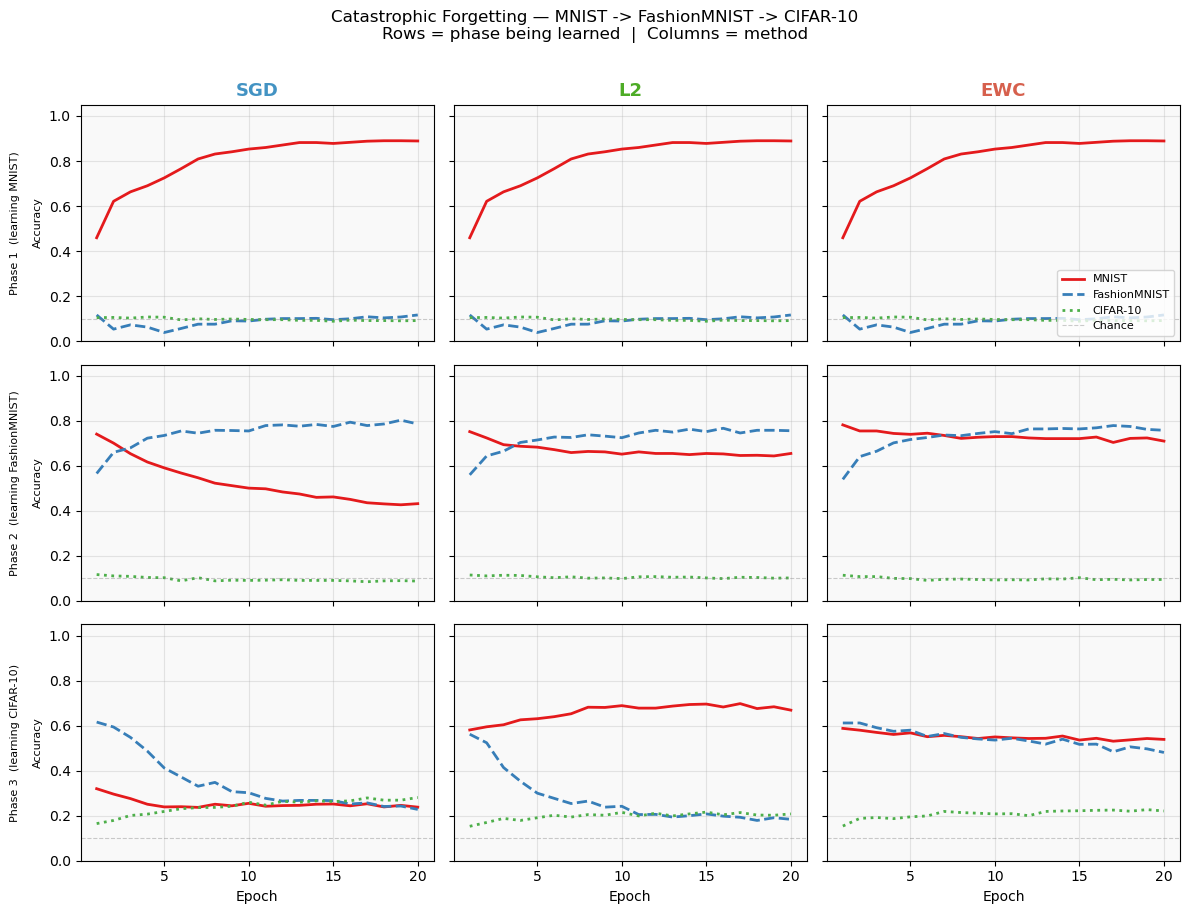

Saved -> catastrophic_forgetting.png


In [15]:
"""
Catastrophic Forgetting Demo — PyTorch
=======================================
Compares SGD / L2 / EWC on 3 sequential tasks:
  Task 1 : MNIST          (handwritten digits)
  Task 2 : FashionMNIST   (clothing items)
  Task 3 : CIFAR-10       (real photos, converted to 28x28 greyscale)

All tasks share the same MLP (784 input, 10 output).
"""

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# ── Config ────────────────────────────────────────────────────
SEED       = 42
BATCH      = 512
HIDDEN     = 512
LAMBDA_L2  = 0.1
LAMBDA_EWC = 300.0
DEVICE     = torch.device("cpu")

EPOCHS  = 20
N_TRAIN = 50_000    # subset per task → fast run (~3-5 min)
N_TEST  = 1_000
LR      = 0.01

torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Transforms ────────────────────────────────────────────────
# All tasks → 28×28 greyscale → flat 784-vector
flat784 = transforms.Compose([
    transforms.Grayscale(),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),
])

# ── Load datasets ─────────────────────────────────────────────
print("Downloading / loading datasets ...")

def make_loaders(ds_train, ds_test):
    tr_idx = torch.randperm(len(ds_train))[:N_TRAIN].tolist()
    te_idx = torch.randperm(len(ds_test))[:N_TEST].tolist()
    train_dl = DataLoader(Subset(ds_train, tr_idx), batch_size=BATCH, shuffle=True)
    test_dl  = DataLoader(Subset(ds_test,  te_idx), batch_size=BATCH, shuffle=False)
    return train_dl, test_dl

mnist_tr   = datasets.MNIST        ("./data", train=True,  download=True, transform=flat784)
mnist_te   = datasets.MNIST        ("./data", train=False, download=True, transform=flat784)
fashion_tr = datasets.FashionMNIST ("./data", train=True,  download=True, transform=flat784)
fashion_te = datasets.FashionMNIST ("./data", train=False, download=True, transform=flat784)
cifar_tr   = datasets.CIFAR10      ("./data", train=True,  download=True, transform=flat784)
cifar_te   = datasets.CIFAR10      ("./data", train=False, download=True, transform=flat784)

train_loaders, test_loaders = zip(
    make_loaders(mnist_tr,   mnist_te),
    make_loaders(fashion_tr, fashion_te),
    make_loaders(cifar_tr,   cifar_te),
)
task_names = ["MNIST", "FashionMNIST", "CIFAR-10"]
print("  Done.\n")

# ── Model ─────────────────────────────────────────────────────
def make_model():
    torch.manual_seed(SEED)
    return nn.Sequential(
        nn.Linear(784, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, HIDDEN), nn.ReLU(),
        nn.Linear(HIDDEN, 10),
    ).to(DEVICE)

# ── Helpers ───────────────────────────────────────────────────
def accuracy(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for xb, yb in loader:
            correct += (model(xb).argmax(1) == yb).sum().item()
            total   += len(yb)
    return correct / total

def snapshot(model):
    return {n: p.clone().detach() for n, p in model.named_parameters()}

def fisher(model, loader, n_samples=200):
    F    = {n: torch.zeros_like(p) for n, p in model.named_parameters()}
    seen = 0
    model.eval()
    for xb, yb in loader:
        for xi, yi in zip(xb, yb):
            if seen >= n_samples: break
            model.zero_grad()
            nn.CrossEntropyLoss()(model(xi.unsqueeze(0)), yi.unsqueeze(0)).backward()
            for n, p in model.named_parameters():
                F[n] += p.grad.detach() ** 2
            seen += 1
        if seen >= n_samples: break
    return {n: v / seen for n, v in F.items()}

# ── Training loop ─────────────────────────────────────────────
def run(method):
    model   = make_model()
    opt     = optim.SGD(model.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()

    snaps, F_accum, anchor = [], None, None
    all_curves = []

    for task_id in range(3):
        loader = train_loaders[task_id]
        curves = [[] for _ in range(3)]

        for _ in range(EPOCHS):
            model.train()
            for xb, yb in loader:
                opt.zero_grad()
                loss = loss_fn(model(xb), yb)

                if method == "l2" and snaps:
                    for snap in snaps:
                        for n, p in model.named_parameters():
                            loss = loss + (LAMBDA_L2 / 2) * (p - snap[n]).pow(2).sum()

                if method == "ewc" and anchor is not None:
                    for n, p in model.named_parameters():
                        loss = loss + (LAMBDA_EWC / 2) * (F_accum[n] * (p - anchor[n]).pow(2)).sum()

                loss.backward()
                opt.step()

            for tid in range(3):
                curves[tid].append(accuracy(model, test_loaders[tid]))

        all_curves.append(curves)

        snap = snapshot(model)
        snaps.append(snap)
        anchor = snap
        if method == "ewc":
            Fn = fisher(model, loader)
            F_accum = Fn if F_accum is None else {n: F_accum[n] + Fn[n] for n in Fn}

    return all_curves

# ── Run all methods ───────────────────────────────────────────
results = {}
for m in ["sgd", "l2", "ewc"]:
    print(f"Training {m.upper()} ...")
    results[m] = run(m)
print("Done.\n")

# ── Plot ──────────────────────────────────────────────────────
method_colors = {"sgd": "#4393c3", "l2": "#4dac26", "ewc": "#d6604d"}
task_colors   = ["#e41a1c", "#377eb8", "#4daf4a"]
task_lines    = ["-", "--", ":"]
epochs_ax     = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(3, 3, figsize=(12, 9), sharex=True, sharey=True)

for col, method in enumerate(["sgd", "l2", "ewc"]):
    for row in range(3):
        ax = axes[row][col]
        for tid in range(3):
            ax.plot(epochs_ax, results[method][row][tid],
                    color=task_colors[tid], linestyle=task_lines[tid],
                    linewidth=2, label=task_names[tid])
        ax.axhline(0.1, color="gray", lw=0.8, ls="--", alpha=0.4, label="Chance")
        ax.set_facecolor("#f9f9f9"); ax.grid(alpha=0.3); ax.set_ylim(0, 1.05)
        if row == 0:
            ax.set_title(method.upper(), fontsize=13, fontweight="bold",
                         color=method_colors[method])
        if col == 0:
            ax.set_ylabel(f"Phase {row+1}  (learning {task_names[row]})\n\nAccuracy", fontsize=8)
        if row == 2:
            ax.set_xlabel("Epoch", fontsize=10)
        if row == 0 and col == 2:
            ax.legend(loc="lower right", fontsize=8)

plt.suptitle(
    "Catastrophic Forgetting — MNIST -> FashionMNIST -> CIFAR-10\n"
    "Rows = phase being learned  |  Columns = method",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig("catastrophic_forgetting.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved -> catastrophic_forgetting.png")